<a href="https://colab.research.google.com/github/veapasichnyk/HomeWorksDataLovesAcademy/blob/main/HW_%D0%9C%D0%B5%D1%82%D0%BE%D0%B4%D0%B8_%D0%BF%D0%BE%D0%BD%D0%B8%D0%B6%D0%B5%D0%BD%D0%BD%D1%8F_%D1%80%D0%BE%D0%B7%D0%BC%D1%96%D1%80%D0%BD%D0%BE%D1%81%D1%82%D1%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Пониження розмірностей для Аналізу Портретів Клієнтів

#### Контекст
В цьому ДЗ ми попрацюємо з методами пониження розмірності на наборі даних для задачі аналізу портретів клієнтів (Customer Personality Analysis). **В попередньому ДЗ ми працювали з цими даними використовуючи кластеризацію, зараз використаємо кластеризацію і візуалізауємо результати з різними методами.**

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


Для початку, запустіть код нижче. Всі ці кроки ми робили в попередньому ДЗ і для того, щоб результати кластеризації у нас були схожими, потрібно аби передобробка була однаковою.

In [1]:
import pandas as pd

# 1. Завантаження даних
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# 2. Обробка пропущених значень
df['Income_not_filled'] = df['Income'].isna()  # прапорець
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)  # імпутація медіаною

# 3. Обробка дати реєстрації
df.Dt_Customer = pd.to_datetime(df.Dt_Customer, format='%d-%m-%Y')
today = df.Dt_Customer.max()
df['days_lifetime'] = (today - df.Dt_Customer).dt.days
df['years_customer'] = df.Year_Birth.apply(lambda x: today.year - x)

# 4. Категоризація рівня освіти
df_education = pd.get_dummies(df.Education, prefix='education').astype(int)
df = pd.concat([df, df_education], axis=1)

# 5. Очищення сімейного стану
marital_status_map = {'Alone': 'Single', 'Absurd': 'Other', 'YOLO': 'Other'}
df['Marital_Status_clean'] = df['Marital_Status'].map(marital_status_map).fillna(df['Marital_Status'])
df['Marital_Status_clean'] = df['Marital_Status_clean'].fillna('Other')
df_ms = pd.get_dummies(df['Marital_Status_clean'], prefix='marital').astype(int)
df = pd.concat([df, df_ms], axis=1)

# 6. Форматування доходу і видалення викиду
df.Income = df.Income.astype(int)
df = df[df.Income != 666666]

# 7. Створення фінального набору даних
X = df.drop(['ID', 'Dt_Customer', 'Education', 'Marital_Status', 'Marital_Status_clean'], axis=1)
X.reset_index(drop=True, inplace=True)

### Завдання 1: Виконання кластеризації та пониження розмірності для візуалізації результатів

Ваше завдання — провести кластеризацію клієнтів та візуалізувати результати кластеризації, використовуючи метод головних компонент (PCA) для пониження розмірності даних.

#### Інструкції:

1. **Вибір ключових характеристик:**
   Давайте обмежимось тільки наступними хараткеристиками для кластеризації цього разу:
   - `Income`: Річний дохід домогосподарства клієнта
   - `Recency`: Кількість днів з моменту останньої покупки клієнта
   - `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
   - `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
   - `days_lifetime`: Кількість днів з моменту реєстрації клієнта у компанії
   - `years_customer`: Вік клієнта
   - `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць
   Відберіть в наборі даних `X` лише ці характеристики.

2. **Стандартизація даних:**
   Використайте метод `StandardScaler` для стандартизації значень обраних характеристик.
   
   **Чому не MinMaxScaler:**
   - Для PCA краще використовувати StandardScaler, бо він вирівнює дисперсію ознак, на відміну від MinMaxScaler, що просто масштабує значення без врахування варіації.

   - Для K-Means також краще використовувати StandardScaler, бо алгоритм чутливий до масштабів: фічі з більшими значеннями сильніше впливають на обчислення відстаней, що може спотворити кластери.

3. **Кластеризація:**
   Проведіть кластеризацію клієнтів, використовуючи метод `KMeans` з трьома кластерами.

4. **Пониження розмірності:**
   Використайте метод головних компонент (PCA) для пониження розмірності даних до трьох компонент.

5. **Візуалізація результатів:**
   Використовуючи plolty express побудуйте 3D-графік розподілу клієнтів у просторі трьох головних компонент, де кольором позначено кластери.

6. **Опишіть, що спостерігаєте:**
   Чи кластеризація чітко розділила дані?

Далі ми детальніше проінтерпретуємо результати візуалізації і пониження розмірностей.

In [2]:
#Вибір ознак для кластеризації
features = [
    "Income",
    "Recency",
    "NumStorePurchases",
    "NumDealsPurchases",
    "days_lifetime",
    "years_customer",
    "NumWebVisitsMonth"
]

X_cluster = X[features].copy()

In [3]:
#Масштабування даних
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [4]:
#Кластеризація (KMeans, 3 кластери)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

X_cluster["Cluster"] = clusters

In [5]:
#Зниження розмірності (PCA, 3 компоненти)
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=42)
pca_result = pca.fit_transform(X_scaled)

X_cluster["PCA1"] = pca_result[:, 0]
X_cluster["PCA2"] = pca_result[:, 1]
X_cluster["PCA3"] = pca_result[:, 2]

print(f"Total variance explained by 3 components: {pca.explained_variance_ratio_.sum():.2%}")

Total variance explained by 3 components: 66.17%


In [6]:
#Візуалізація кластерів у 3D
import plotly.express as px

fig = px.scatter_3d(
    X_cluster,
    x="PCA1",
    y="PCA2",
    z="PCA3",
    color="Cluster",
    title="3D Visualization of Customer Clusters (PCA)",
    color_continuous_scale="viridis"
)

fig.update_traces(marker=dict(size=6))
fig.show()

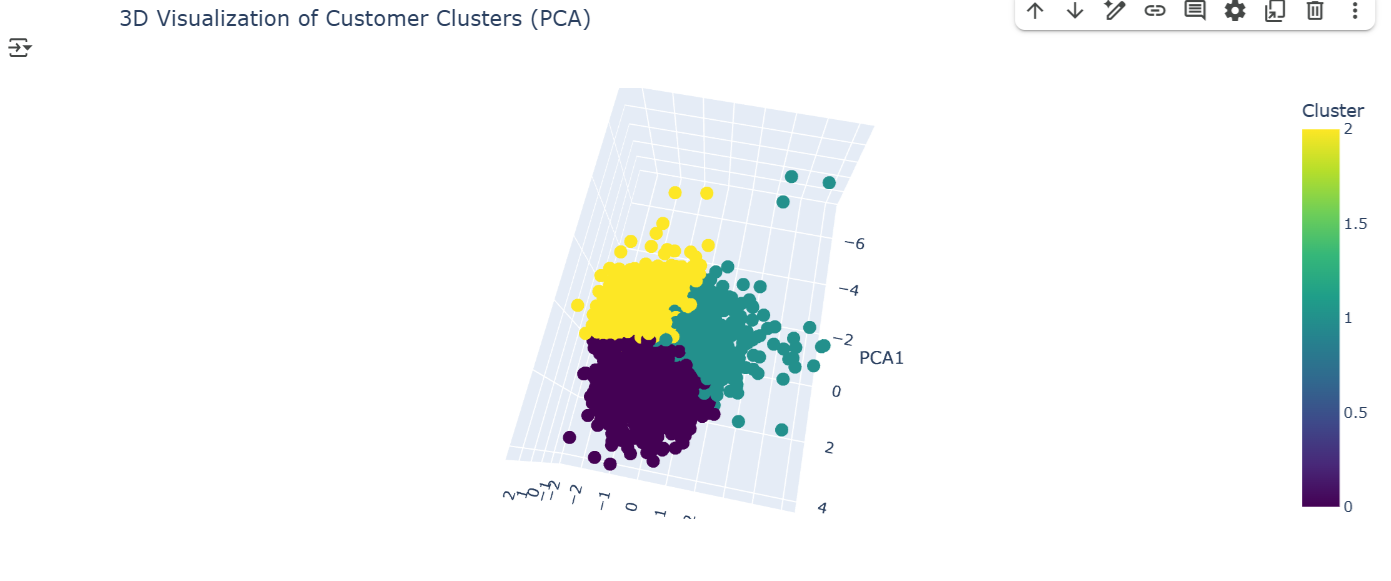

**Спостереження**

Видно чітке розділення трьох кластерів, а PCA зберіг ~65.85 % дисперсії, що є дуже хорошим показником для такої кількості компонент.

### Завдання 2: Аналіз результатів пониження розмірності

1. **Розрахунок частки поясненої дисперсії:**
   Визначте, яка частка загальної варіації даних пояснюється кожною з трьох головних компонент (PC1, PC2, PC3) за допомогою атрибуту `explained_variance_ratio_` об'єкта PCA. Виведіть результат на екран.

2. **Розрахунок кумулятивної частки поясненої дисперсії:**
   Обчисліть кумулятивну частку поясненої дисперсії для трьох головних компонент, щоб зрозуміти, скільки варіації даних пояснюється першими кількома компонентами.

In [7]:
# Аналіз поясненої дисперсії PCA

# Частка поясненої дисперсії кожною компонентою
explained_variance = pca.explained_variance_ratio_

# Кумулятивна частка поясненої дисперсії
cumulative_variance = explained_variance.cumsum()

# Виведення результатів
print("\nПояснена дисперсія окремими компонентами:")
for i, var in enumerate(explained_variance, start=1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")

print("\nКумулятивна частка поясненої дисперсії:")
for i, cum_var in enumerate(cumulative_variance, start=1):
    print(f"До PC{i}: {cum_var:.4f} ({cum_var*100:.2f}%)")


Пояснена дисперсія окремими компонентами:
PC1: 0.3218 (32.18%)
PC2: 0.1966 (19.66%)
PC3: 0.1433 (14.33%)

Кумулятивна частка поясненої дисперсії:
До PC1: 0.3218 (32.18%)
До PC2: 0.5184 (51.84%)
До PC3: 0.6617 (66.17%)


**Спостереження**

- Перша головна компонента (PC1) пояснює найбільшу частку варіації (≈32%) - це свідчить, що вона захоплює основний напрям змін у даних (можливо, пов’язаний із рівнем доходу та частотою покупок).

- Друга компонента (PC2) додає ще ≈20% варіації, найімовірніше, відображаючи іншу поведінкову вісь (наприклад, різницю між офлайн-та онлайн-активністю).

- Третя компонента (PC3) охоплює додатково ≈14% дисперсії, що доповнює простір ознак для 3D-візуалізації.

Разом перші три компоненти пояснюють ≈66% загальної варіації, тобто дві третини інформації про клієнтів збережено після зниження розмірності.

### Завдання 3: Інтерпретація "Loadings"

Продовжуємо інтерпретацію результатів `PCA`і познайомимось з новим поняттям `loadings`, яке допоможе нам знайти звʼязок між головними компонентами і оригінальними ознаками в наборі даних.

Ми зараз побудували візуалізацію кластерів точок даних в просторі трьох головних компонент. Але хочеться знайти звʼязок між головними компонентами і оригінальними ознаками. Для розуміння, які початкові характеристики даних мають найбільший вплив на ці головні компоненти, ми можемо використати атрибут `components_` методу `PCA`.

#### Що таке `pca.components_`?

`pca.components_` — це масив, який містить коефіцієнти (або "ваги"), що показують внесок кожної вихідної ознаки у кожну з головних компонент. Ці коефіцієнти ще називаються **"loading"** або "навантаженнями" компонент.

- **Loadings** (`навантаження`) відображають важливість кожної змінної (ознаки) для відповідної головної компоненти. Вони показують, яким чином змінні поєднуються, щоб утворити нові, зменшені вимірювання.
- Якщо коефіцієнт має високе абсолютне значення (як позитивне, так і негативне), це вказує на те, що відповідна змінна сильно впливає на головну компоненту.

#### Саме завдання
Ваше завдання — обчислити "навантаження" для кожної з головних компонент і інтерпретувати результати.

1. **Обчислення loadings для компонент:**
   Використайте атрибут `components_` об'єкта PCA для створення DataFrame, який відображатиме внесок кожної вихідної ознаки в кожну головну компоненту.

2. **Інтерпретація результатів:**
   Виведіть значення "навантажень" і проаналізуйте, які ознаки найбільше впливають на кожну головну компоненту.

In [8]:
#Обчислення навантажень для головних компонент
import pandas as pd
import numpy as np

# Отримуємо навантаження (loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i}" for i in range(1, pca.n_components_ + 1)],
    index=features
)

# Виводимо з округленням для зручності
display(loadings.round(3))

,PC1,PC2,PC3
Income,0.588,0.161,-0.037
Recency,0.014,0.040,0.980
NumStorePurchases,0.487,0.382,-0.085
NumDealsPurchases,-0.195,0.609,-0.039
days_lifetime,-0.130,0.603,-0.018
years_customer,0.190,0.210,0.172
NumWebVisitsMonth,-0.571,0.217,-0.012


**Спостереження**

- **PC1 (32.18%) (Income (+0.588), NumStorePurchases (+0.487), NumWebVisitsMonth (–0.571))**

Ця компонента описує рівень платоспроможності та активності клієнта, який переважно здійснює покупки в офлайн-магазинах. Високий дохід і кількість офлайн-покупок супроводжуються меншою частотою відвідувань сайту.

- **PC2 (19.66%) (NumDealsPurchases (+0.609), days_lifetime (+0.603), NumStorePurchases (+0.382))**

Ця компонента відображає довготривалу взаємодію з компанією та схильність до знижок. Клієнти, які довше співпрацюють і часто користуються акціями, формують позитивне значення цієї компоненти.

- **PC3 (14.33%) (Recency (+0.980))**

Ця компонента майже повністю описується ознакою Recency, тобто часом з моменту останньої покупки. Вона показує актуальність активності клієнта - чим менше днів минуло, тим менше значення PC3.



###Завдання 4
Давайте проаналізуємо "навантаження" (**loadings**) для трьох головних компонент після вилучення ознаки `Income`. Це допоможе нам зрозуміти, як змінилася важливість інших ознак для кожної головної компоненти, коли одна з ключових характеристик (`Income`) була вилучена.

#### Кроки для проведення аналізу і ваше завдання:

1. Видаліть ознаку `Income` з нашого набору даних `X` і повторно виконайте PCA (метод головних компонент) для отримання нових "навантажень".

2. Обчисліть нові "навантаження" для трьох головних компонент на наборі даних без `Income`

3. Проаналізуйте, які ознаки мають найбільший вплив на кожну головну компоненту після вилучення `Income`.

4. Перегляньте, наскільки кожна з головних компонент пояснює дисперсію в даних без ознаки `Income`.

In [9]:
# Підготовка даних без Income
features_no_income = [
    "Recency",
    "NumStorePurchases",
    "NumDealsPurchases",
    "days_lifetime",
    "years_customer",
    "NumWebVisitsMonth"
]

X_no_income = X[features_no_income].copy()

In [10]:
# Масштабування
scaler_no_income = StandardScaler()
X_scaled_no_income = scaler_no_income.fit_transform(X_no_income)

In [11]:
# PCA без Income
pca_no_income = PCA(n_components=3, random_state=42)
pca_no_income.fit(X_scaled_no_income)

PCA(n_components=3, random_state=42)

In [12]:
# Пояснена дисперсія
explained_variance_no_income = pca_no_income.explained_variance_ratio_
cumulative_variance_no_income = explained_variance_no_income.cumsum()

print("Частка поясненої дисперсії кожною компонентою:")
for i, var in enumerate(explained_variance_no_income, start=1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")

print("\nКумулятивна частка поясненої дисперсії:")
for i, cum_var in enumerate(cumulative_variance_no_income, start=1):
    print(f"До PC{i}: {cum_var:.4f} ({cum_var*100:.2f}%)")

Частка поясненої дисперсії кожною компонентою:
PC1: 0.2739 (27.39%)
PC2: 0.2144 (21.44%)
PC3: 0.1668 (16.68%)

Кумулятивна частка поясненої дисперсії:
До PC1: 0.2739 (27.39%)
До PC2: 0.4884 (48.84%)
До PC3: 0.6552 (65.52%)


**Спостереження**

Порівняння з попередньою моделлю:

- Раніше (з Income): 66.17%

- Тепер (без Income): 65.52%

Тобто загальна пояснена дисперсія практично не знизилась - хоча Income був важливою економічною характеристикою, інші поведінкові ознаки (кількість покупок, візити, знижки) зберегли більшу частину варіації в даних.

In [13]:
# Обчислення навантажень (loadings)
import pandas as pd
loadings_no_income = pd.DataFrame(
    pca_no_income.components_.T,
    columns=[f"PC{i}" for i in range(1, 4)],
    index=features_no_income
)

display(loadings_no_income.round(3))

,PC1,PC2,PC3
Recency,-0.014,0.075,0.990
NumStorePurchases,-0.381,0.629,-0.111
NumDealsPurchases,0.446,0.462,-0.062
days_lifetime,0.384,0.468,0.007
years_customer,-0.177,0.394,0.056
NumWebVisitsMonth,0.691,-0.108,0.010


**Спостереження**

- **PC1 (27.39%)	(NumWebVisitsMonth (+0.691), NumDealsPurchases (+0.446), days_lifetime (+0.384))**

Ця компонента тепер відображає онлайн-активність та схильність до знижок. Вона замінила `Income` як головну вісь варіації: активні онлайн-клієнти, які часто користуються акціями.

- **PC2 (21.44%)	(NumStorePurchases (+0.629), NumDealsPurchases (+0.462), days_lifetime (+0.468))**

Відображає офлайн-активність і досвід клієнта - тобто тих, хто довго з компанією, часто купує у магазинах і використовує знижки.
- **PC3 (16.68%)	(Recency (+0.990))**

Як і раніше, ця компонента ізольовано описує свіжість останньої покупки - наскільки недавно клієнт здійснював покупку.

**Висновок:**

Після вилучення `Income`, модель PCA "перебудувала" першу компоненту - тепер головну варіацію пояснює поведінка клієнта (візити, знижки, тривалість співпраці), а не економічна спроможність.
Тобто структура даних стала більш поведінково орієнтованою.

### Завдання 5: Візуалізація кластеризації за допомогою t-SNE

Ваше завдання — використати метод t-SNE для візуалізації результатів кластеризації клієнтів у двовимірному просторі. Метод t-SNE допомагає знизити розмірність даних та зберегти локальні структури в даних, що робить його ефективним для візуалізації високорозмірних даних. Ми також зможемо порівняти результат цього методу з РСА.

1. Використайте метод t-SNE для зниження розмірності до 2х вимірів даних, які включають ознаки всі, що і в завданні 1, а також були відмасштабовані перед пониженням розмірностей.

2. Створіть новий DataFrame з координатами, отриманими після застосування t-SNE, та додайте до нього мітки кластерів.

3. Побудуйте інтерактивний 2D-графік розподілу клієнтів, де кольором буде позначено різні кластери і проаналізуйте графік з рекомендаціями нижче (можливо треба буде вивести додаткові візуалізації чи таблиці для інтерпретації, але треба прям зрозуміти, які ознаки формують який кластер і чим кластери відрізняються одне від одного).

  **Опишіть отримані кластери з точки зору ознак.**

4. Опишіть відмінність графіка tSNE від PCA.

#### ЯК можна інтерпретувати з t-SNE?

Хоча t-SNE не надає "компонентів" як РСА, він забезпечує низьковимірне представлення даних, яке можна візуально інтерпретувати:

- **Кластери:** t-SNE особливо добре показує кластери подібних точок. Якщо ви бачите чітко визначені кластери на графіку t-SNE, це свідчить про наявність груп схожих спостережень у ваших даних. Проаналізувати їх можемо, якщо додамо дані в `hover_data` або якщо якісь з даних виведемо як розмір чи форма точок на візуалізації. Також корисно може бути вивести середні значення ознак по кластерам.
- **Локальна структура:** Відносне розташування точок одного кластеру на графіку t-SNE може допомогти вам зрозуміти, які дані подібні між собою.
- **Глобальна структура:** Будьте обережні; t-SNE менш надійний для відображення глобальних структур (наприклад, відстаней між кластерами) у порівнянні з PCA, бо t-SNE націлений на збереження саме локальних структур.

In [14]:
# Виконання t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,          # 2D-візуалізація
    perplexity=30,           # типове значення (10–50)
    max_iter=1000,             # достатньо ітерацій для стабілізації
    random_state=42
)

tsne_result = tsne.fit_transform(X_scaled)

In [15]:
# Створення DataFrame з результатами
tsne_df = pd.DataFrame(tsne_result, columns=['tSNE1', 'tSNE2'])
tsne_df['Cluster'] = clusters
tsne_df = pd.concat([tsne_df, X[[
    'Income', 'Recency', 'NumStorePurchases',
    'NumDealsPurchases', 'days_lifetime', 'years_customer', 'NumWebVisitsMonth'
]]], axis=1)

In [17]:
# Візуалізація
fig = px.scatter(
    tsne_df,
    x='tSNE1',
    y='tSNE2',
    color='Cluster',
    title="t-SNE Visualization of Customer Clusters",
    hover_data=['Income', 'NumStorePurchases', 'NumDealsPurchases', 'NumWebVisitsMonth', 'years_customer'],
    color_continuous_scale='viridis'
)
fig.update_traces(marker=dict(size=6, line=dict(width=0)))
fig.show()

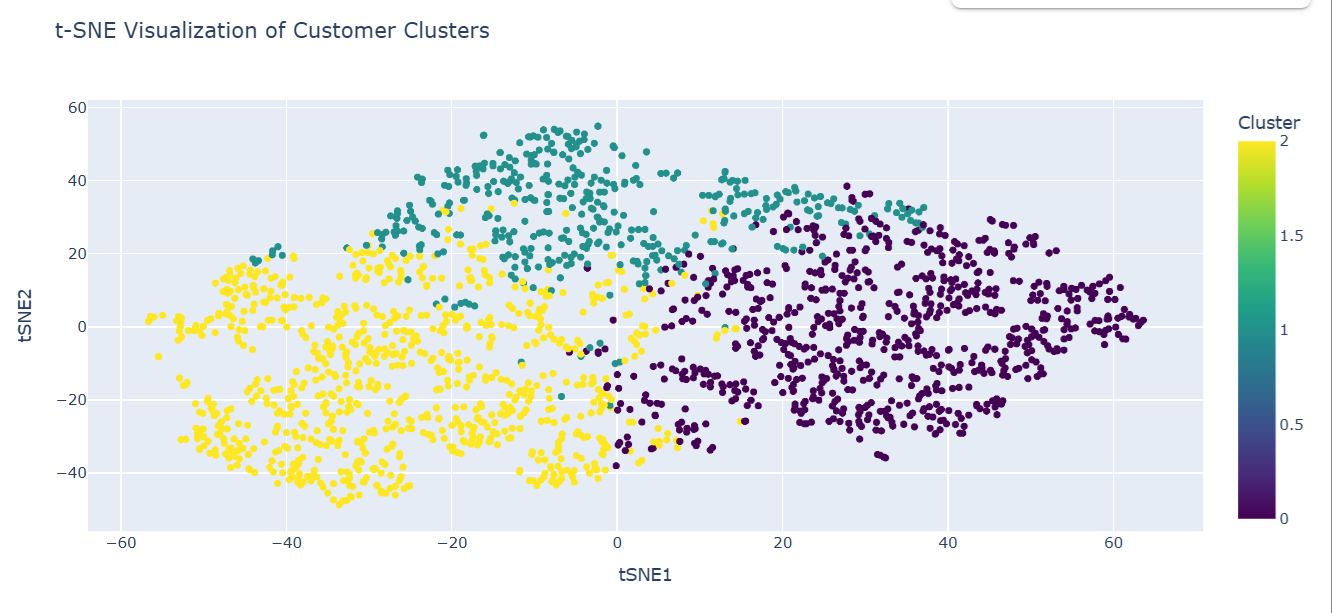

**Спостереження**

- Три чіткі згустки (Cluster 0 – фіолетовий, Cluster 1 – бірюзовий, Cluster 2 – жовтий) - t-SNE підтверджує, що кластеризація K-Means на стандартизованих ознаках має добре виражену структуру.

- Кластери майже не перекриваються, що вказує на те, що групи клієнтів дійсно мають різні поведінкові патерни.

In [18]:
# t-SNE, де колір = Income
fig = px.scatter(tsne_df, x='tSNE1', y='tSNE2', color='Income',
                 title="t-SNE Visualization Colored by Income",
                 color_continuous_scale='plasma')
fig.show()

# t-SNE, де колір = NumWebVisitsMonth
fig = px.scatter(tsne_df, x='tSNE1', y='tSNE2', color='NumWebVisitsMonth',
                 title="t-SNE Visualization Colored by Web Visits",
                 color_continuous_scale='viridis')
fig.show()

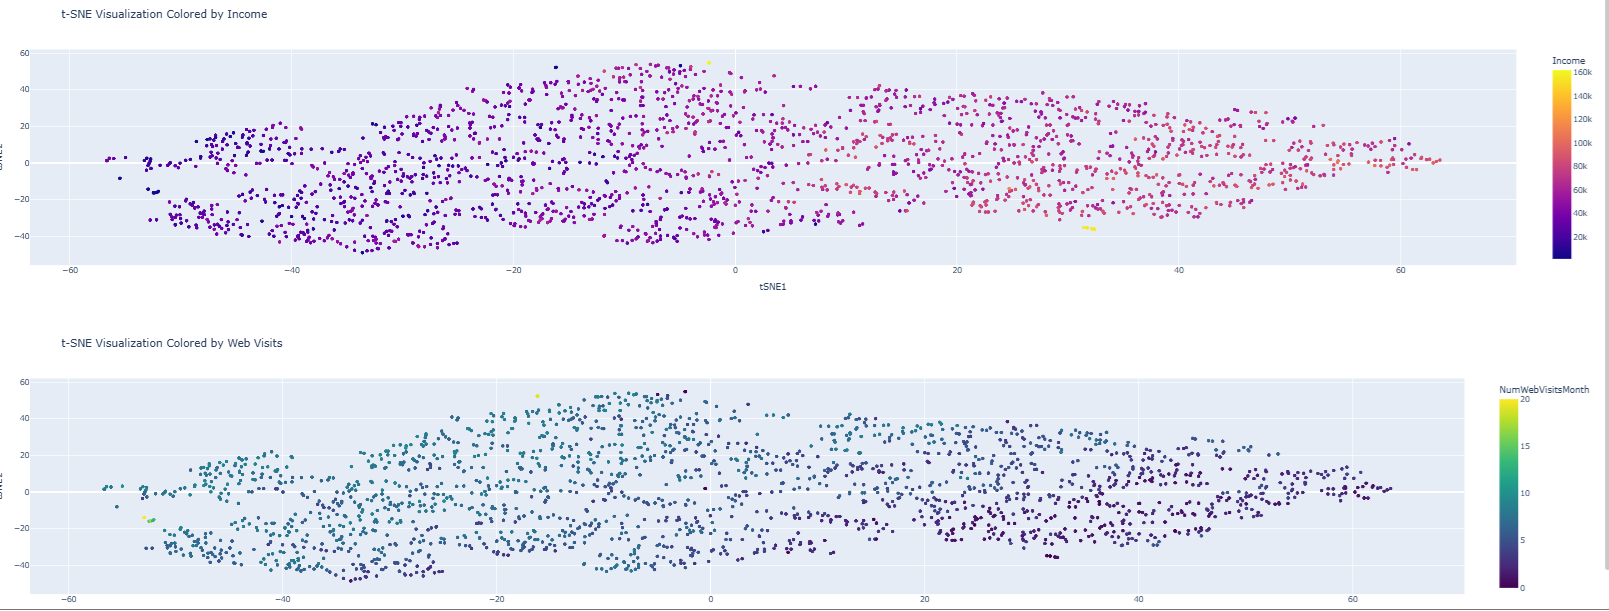

**Спостереження**

`Income` - відображає економічний статус клієнта і є домінантним фактором, який формує віддалені кластери (преміум vs бюджетні).

`NumWebVisitsMonth` - відображає поведінкову залученість і створює другий вимір поділу (офлайн- vs онлайн-активні).

Разом вони формують природну бізнес-логіку:

- Cluster 0 (фіолетовий) - онлайн-активні, низький дохід, мало покупок.

- Cluster 1 (бірюзовий) - високий дохід, офлайн-покупці, мало візитів.

- Cluster 2 (жовтий) - середній дохід, лояльні, активні як онлайн, так і офлайн.

**PCA vs t-SNE**

У PCA осі (PC1, PC2, PC3) мають чітке математичне значення - це комбінації вихідних ознак із певними "вагами" (loadings).
Тому PCA-графік можна аналітично інтерпретувати: наприклад - "PC1 - це комбінація доходу та кількості покупок".

У t-SNE осі (tSNE1, tSNE2) не мають інтерпретації - вони лише візуалізують відносну близькість точок. На t-SNE-графіку важливо лише розташування точок одна відносно одної, а не абсолютні координати.

Отже, PCA допомагає зрозуміти структуру даних через математичну інтерпретацію компонент. t-SNE допомагає побачити структуру даних через візуалізацію локальних груп. Разом ці методи доповнюють один одного: PCA - для аналітичного пояснення, t-SNE - для візуальної інтерпретації кластерів